# This is a basic tool for graph (or network, we shall use the terms interchangeably) creation and traversal.

This tutorial MUST be read in conjunction witth the official networkx documentation, which is available from: https://networkx.org/documentation/stable/reference/introduction.html


In [ ]:
import networkx as nx
#seed=1000           # seed the graph for reproducibility, you should be doing this
G= nx.gnp_random_graph (5,.5)       # here we create a random binomial graph with 5 nodes and an average (expected) connectivity of 5*.5= 2.5.
print ( G.nodes() )

[0, 1, 2, 3, 4]


In [ ]:
# Graph for Part B R2
G= nx.Graph ()
G.add_edge(0, 2, weight=11)        # creation of graph with the required edges for R2 of Part B.
G.add_edge(0, 4, weight=7)       # This graph MUST be used without modification for Part B
G.add_edge(1, 2, weight=4)
G.add_edge(2, 3, weight=9)
G.add_edge(3, 4, weight=3)

In [ ]:
print(G.edges())                  # verify the connectivity of G

[(0, 2), (0, 4), (2, 1), (2, 3), (4, 3)]


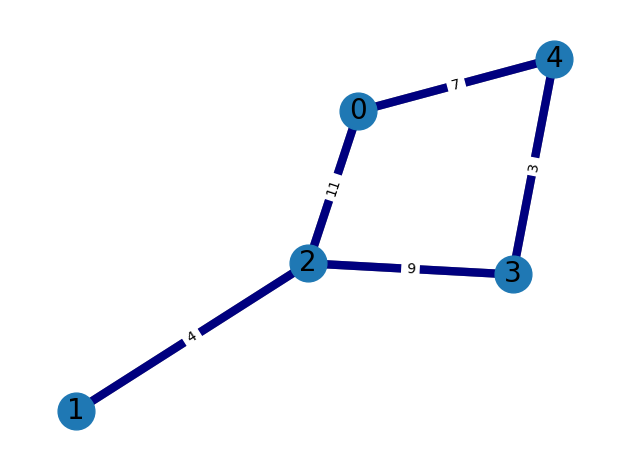

In [ ]:
import matplotlib.pyplot as plt          # visualize the graph connected
import networkx as nx

e = [(u, v) for (u, v, d) in G.edges(data=True) ]
pos = nx.spring_layout(G, seed=7)  # positions for all nodes - seed for reproducibility

# nodes
nx.draw_networkx_nodes(G, pos, node_size=700)

# edges
nx.draw_networkx_edges(G, pos, edgelist=e, width=6)
nx.draw_networkx_edges(
    G, pos, edgelist=e, width=6, alpha=0.5, edge_color="b")

# node labels
nx.draw_networkx_labels(G, pos, font_size=20, font_family="sans-serif")
# edge weight labels
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels)

ax = plt.gca()
ax.margins(0.08)
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
list(nx.dfs_edges(G, source=2))

[(2, 0), (0, 4), (4, 3), (2, 1)]

In [ ]:
nx.astar_path(G,2,4)

[2, 3, 4]

In [ ]:
# values for R2
simulationTime = 36000
T= 100
f= 0.6
k=3

In [ ]:
#store how many trips happend between each pair of nodes
tripMatrix=[[0 for j in range (5)]for i in range(5)]

In [ ]:
import random

In [ ]:
def collectTrafficData(network, tripMatrix, tripsPerTick):
  # run the simulation for 10 hours
  for tick in range(simulationTime):
    #create 100trips each second
    for i in range(tripsPerTick):
      start = random.randint(0,len(network)-1)
      end= random.randint(0,len(network)-1)
      #start and end need to be different
      while end == start:
        end = random.randint(0,len(network)-1)

      #find the shortest path for this trip
      path = nx.astar_path(network,start,end,weight="weight")

      #count this trip
      tripMatrix[start][end]+=1

In [ ]:
random.seed(1000)
collectTrafficData(G, tripMatrix, T)

In [ ]:
print (G.edges())
print (nx.is_connected(G))

[(0, 2), (0, 4), (2, 1), (2, 3), (4, 3)]
True


In [ ]:
tripMatrix = [[0 for j in range(5)] for i in range(5)]

random.seed(1000)
collectTrafficData(G,tripMatrix,T)


In [ ]:
def calculateSingleBenefit(X, Y, network, tripMatrix, f):

    # current shortest distance
    shortXY = nx.astar_path_length(network, X, Y, weight="weight")

    # length of the new road
    newRoad = f * shortXY

    # trips directly between X and Y
    directTrips = tripMatrix[X][Y] + tripMatrix[Y][X]

    # starting benefit
    benefit = (shortXY - newRoad) * directTrips

    # check neighbors of Y
    for n1 in network.neighbors(Y):

        currentDist = nx.astar_path_length(network, X, n1, weight="weight")

        savings = currentDist - newRoad - network[Y][n1]["weight"]

        if savings > 0:

            trips = tripMatrix[X][n1] + tripMatrix[n1][X]

            benefit += savings * trips

    # check neighbors of X
    for n2 in network.neighbors(X):

        currentDist = nx.astar_path_length(network, Y, n2, weight="weight")

        savings = currentDist - newRoad - network[X][n2]["weight"]

        if savings > 0:

            trips = tripMatrix[Y][n2] + tripMatrix[n2][Y]

            benefit += savings * trips

    return benefit

In [ ]:
def computeAllBenefits(network, tripMatrix, f):

    benefitMatrix = [[-1 for j in range(len(network))]
                     for i in range(len(network))]

    for X in range(len(network) - 1):

        for Y in range(X + 1, len(network)):

            if not network.has_edge(X, Y):

                value = calculateSingleBenefit(
                    X, Y, network, tripMatrix, f)

                benefitMatrix[X][Y] = value
                benefitMatrix[Y][X] = value

    return benefitMatrix

In [ ]:
benefitMatrix = computeAllBenefits(G, tripMatrix, f)

In [ ]:
candidateRoads = [
    (0, 1),
    (0, 3),
    (1, 3),
    (1, 4),
    (2, 4)
]

print("Benefit values")

for u, v in candidateRoads:

    print((u, v), "=", benefitMatrix[u][v])

Benefit values
(0, 1) = 2161206.0
(0, 3) = 1438520.0
(1, 3) = 3742226.8
(1, 4) = 2443831.6000000006
(2, 4) = 3450518.4000000004


In [ ]:
bestRoad = None
bestBenefit = -1

for u, v in candidateRoads:

    if benefitMatrix[u][v] > bestBenefit:

        bestBenefit = benefitMatrix[u][v]
        bestRoad = (u, v)

print("First road to build:", bestRoad)
print("Benefit:", bestBenefit)

First road to build: (1, 3)
Benefit: 3742226.8


In [ ]:
u, v = bestRoad

distance = f * nx.astar_path_length(G, u, v, weight="weight")

G.add_edge(u, v, weight=distance)

In [ ]:
benefitMatrix = computeAllBenefits(G, tripMatrix, f)

In [ ]:
bestRoad2 = None
bestBenefit2 = -1

for u, v in candidateRoads:

    if G.has_edge(u, v):
        continue

    if benefitMatrix[u][v] > bestBenefit2:

        bestBenefit2 = benefitMatrix[u][v]
        bestRoad2 = (u, v)

print("Second road to build:", bestRoad2)
print("Benefit:", bestBenefit2)

Second road to build: (1, 4)
Benefit: 2646288.08


In [ ]:
# R3 graph

N = 60
p = 0.05

while True:

    G = nx.gnp_random_graph(N, p)

    # give every road a random length
    for u, v in G.edges():
        G[u][v]["weight"] = random.randint(5, 25)

    if nx.is_connected(G):
        break

    p += 0.01

print("Connected graph is created")
print("Connectivity =", p)

Connected graph is created
Connectivity = 0.060000000000000005


In [ ]:
tripMatrix = [[0 for j in range(N)] for i in range(N)]

In [ ]:
random.seed(1000)

collectTrafficData(G, tripMatrix, T)

In [ ]:
f= 0.6

In [ ]:
benefitMatrix = computeAllBenefits(G, tripMatrix, f)

In [ ]:
roads = []

for i in range(N - 1):

    for j in range(i + 1, N):

        if benefitMatrix[i][j] != -1:

            roads.append((benefitMatrix[i][j], i, j))

roads.sort(reverse=True)

print("Top", k, "roads")

for i in range(k):

    benefit, u, v = roads[i]

    print(
        "Road", i + 1,
        ":", (u, v),
        "Benefit =", benefit
    )

Top 3 roads
Road 1 : (12, 44) Benefit = 305290.0
Road 2 : (31, 44) Benefit = 289002.80000000005
Road 3 : (43, 44) Benefit = 280014.00000000006


In [ ]:
print("Top", k, "roads")

for i in range(k):
    benefit, u, v = roads[i]
    print("Road", i + 1, ":", (u, v), "Benefit =", benefit)

Top 3 roads
Road 1 : (12, 44) Benefit = 305290.0
Road 2 : (31, 44) Benefit = 289002.80000000005
Road 3 : (43, 44) Benefit = 280014.00000000006


In [ ]:
# R4 graph

N = 60
p = 0.05

while True:

    G = nx.gnp_random_graph(N, p)

    # give every road a random length
    for u, v in G.edges():
        G[u][v]["weight"] = random.randint(5, 25)

    if nx.is_connected(G):
        break

    p += 0.01

print("Connected graph is created")
print("Connectivity =", p)

Connected graph is created
Connectivity = 0.07


In [ ]:
tripMatrix = [[0 for j in range(N)] for i in range(N)]

In [ ]:
random.seed(1000)

collectTrafficData(G, tripMatrix, T)

In [ ]:
f= 0.8

In [ ]:
benefitMatrix = computeAllBenefits(G, tripMatrix, f)

In [ ]:
roads = []

for i in range(N - 1):

    for j in range(i + 1, N):

        if benefitMatrix[i][j] != -1:

            roads.append((benefitMatrix[i][j], i, j))

roads.sort(reverse=True)

print("Top", k, "roads")

for i in range(k):

    benefit, u, v = roads[i]

    print(
        "Road", i + 1,
        ":", (u, v),
        "Benefit =", benefit
    )

Top 3 roads
Road 1 : (1, 15) Benefit = 145323.19999999998
Road 2 : (1, 17) Benefit = 139904.39999999997
Road 3 : (1, 19) Benefit = 117695.0


In [ ]:
print("Top", k, "roads")

for i in range(k):
    benefit, u, v = roads[i]
    print("Road", i + 1, ":", (u, v), "Benefit =", benefit)

Top 3 roads
Road 1 : (1, 15) Benefit = 145323.19999999998
Road 2 : (1, 17) Benefit = 139904.39999999997
Road 3 : (1, 19) Benefit = 117695.0


In [ ]:
# R5 graph

N = 60
p = 0.14

while True:

    G = nx.gnp_random_graph(N, p)

    # give every road a random length
    for u, v in G.edges():
        G[u][v]["weight"] = random.randint(5, 25)

    if nx.is_connected(G):
        break

    p += 0.01

print("Connected graph is created")
print("Connectivity =", p)

Connected graph is created
Connectivity = 0.14


In [ ]:
tripMatrix = [[0 for j in range(N)] for i in range(N)]

In [ ]:
random.seed(1000)

collectTrafficData(G, tripMatrix, T)

In [ ]:
f= 0.6

In [ ]:
benefitMatrix = computeAllBenefits(G, tripMatrix, f)

In [ ]:
roads = []

for i in range(N - 1):

    for j in range(i + 1, N):

        if benefitMatrix[i][j] != -1:

            roads.append((benefitMatrix[i][j], i, j))

roads.sort(reverse=True)

print("Top", k, "roads")

for i in range(k):

    benefit, u, v = roads[i]

    print(
        "Road", i + 1,
        ":", (u, v),
        "Benefit =", benefit
    )

Top 3 roads
Road 1 : (45, 46) Benefit = 204580.40000000005
Road 2 : (7, 46) Benefit = 199460.80000000002
Road 3 : (20, 38) Benefit = 180223.20000000004


In [ ]:
print("Top", k, "roads")

for i in range(k):
    benefit, u, v = roads[i]
    print("Road", i + 1, ":", (u, v), "Benefit =", benefit)

Top 3 roads
Road 1 : (45, 46) Benefit = 204580.40000000005
Road 2 : (7, 46) Benefit = 199460.80000000002
Road 3 : (20, 38) Benefit = 180223.20000000004
